# Kunci Jawaban - Linear Regression

- **Dataset:** Air Quality
- **Sumber:** https://archive.ics.uci.edu/dataset/360/air+quality
- **Target:** `CO(GT)`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [ ]:
%pip install ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE dan nilai missing.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, dan scatter plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Air Quality menggunakan ID dataset dari UCI.

In [5]:
air_quality = fetch_ucirepo(id=360)

### Ambil data utama

Simpan data utama ke DataFrame bernama `df`.

In [6]:
df = air_quality.data.features.copy()

### Tentukan kolom target

Simpan nama kolom target ke variabel `TARGET_COL`.

In [7]:
TARGET_COL = "CO(GT)"

### Tentukan kolom yang tidak digunakan

Simpan kolom tanggal, waktu, dan kolom dengan terlalu banyak nilai sentinel.

In [8]:
DROP_COLS = ["Date", "Time", "NMHC(GT)"]

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom dataset.

In [9]:
df.shape

(9357, 15)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki **9357 baris** dan **15 kolom**.

> Kolom mana yang dipakai sebagai target?

Jawaban: Kolom target yang dipakai adalah `CO(GT)`.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat bentuk data.

In [10]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.600,1360,150,11.900,1046,166,1056,113,1692,1268,13.600,48.900,0.758
1,3/10/2004,19:00:00,2.000,1292,112,9.400,955,103,1174,92,1559,972,13.300,47.700,0.726
2,3/10/2004,20:00:00,2.200,1402,88,9.000,939,131,1140,114,1555,1074,11.900,54.000,0.750
3,3/10/2004,21:00:00,2.200,1376,80,9.200,948,172,1092,122,1584,1203,11.000,60.000,0.787
4,3/10/2004,22:00:00,1.600,1272,51,6.500,836,131,1205,116,1490,1110,11.200,59.600,0.789


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Tidak, kolom `Date` dan `Time` berisi teks/tanggal, sedangkan kolom lain berisi angka.

> Apakah semua kolom akan langsung dipakai untuk modeling?

Jawaban: Tidak, kolom `Date`, `Time`, dan `NMHC(GT)` akan dihapus agar modeling tetap sederhana.

## 3 - Data Understanding

### Tampilkan informasi dataset

Gunakan `info()` untuk melihat tipe data dan jumlah data non-null.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Dataset memiliki kolom `object`, `int64`, dan `float64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Output `info()` tidak menunjukkan missing value, tetapi dataset ini memakai nilai sentinel `-200` untuk menandai data hilang.

### Cek missing value standar

Hitung jumlah missing value standar pada setiap kolom.

In [12]:
df.isna().sum()

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

> Berdasarkan output, apakah ada missing value standar?

Jawaban: Tidak ada missing value standar yang terbaca oleh pandas.

> Mengapa masih perlu cek nilai sentinel?

Jawaban: Karena dokumentasi dataset menggunakan nilai `-200` sebagai tanda data hilang.

### Cek nilai sentinel -200

Hitung jumlah nilai `-200` pada setiap kolom.

In [13]:
(df == -200).sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

> Berdasarkan output, kolom mana yang memiliki nilai sentinel paling banyak?

Jawaban: Kolom `NMHC(GT)` memiliki nilai sentinel paling banyak, yaitu **8443**.

> Apa arti nilai `-200` pada dataset ini?

Jawaban: Nilai `-200` diperlakukan sebagai missing value yang perlu dibersihkan.

### Cek jumlah duplikat

Hitung jumlah baris yang duplikat penuh.

In [14]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh pada dataset awal adalah **0**.

> Apa keputusan cleaning yang perlu dilakukan?

Jawaban: Tidak ada duplikat awal yang perlu dihapus, tetapi nilai sentinel tetap harus ditangani.

### Tampilkan statistik deskriptif

Gunakan `describe()` untuk melihat ringkasan nilai numerik pada dataset.

In [15]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000,9357.000,9357.000,9357.000,9357.000,9357.000,9357.000,9357.000,9357.000,9357.000,9357.000,9357.000,9357.000
mean,-34.208,1048.990,-159.090,1.866,894.595,168.617,794.990,58.149,1391.480,975.072,9.778,39.485,-6.838
std,77.657,329.833,139.789,41.380,342.333,257.434,321.994,126.940,467.210,456.938,43.204,51.216,38.977
min,-200.000,-200.000,-200.000,-200.000,-200.000,-200.000,-200.000,-200.000,-200.000,-200.000,-200.000,-200.000,-200.000
25%,0.600,921.000,-200.000,4.000,711.000,50.000,637.000,53.000,1185.000,700.000,10.900,34.100,0.692
50%,1.500,1053.000,-200.000,7.900,895.000,141.000,794.000,96.000,1446.000,942.000,17.200,48.600,0.977
75%,2.600,1221.000,-200.000,13.600,1105.000,284.000,960.000,133.000,1662.000,1255.000,24.100,61.900,1.296
max,11.900,2040.000,1189.000,63.700,2214.000,1479.000,2683.000,340.000,2775.000,2523.000,44.600,88.700,2.231


> Berdasarkan statistik deskriptif, apa tanda bahwa dataset memiliki nilai sentinel?

Jawaban: Beberapa kolom memiliki nilai minimum **-200**, yang menunjukkan adanya nilai sentinel.

> Mengapa nilai sentinel harus diubah sebelum modeling?

Jawaban: Nilai sentinel bukan nilai pengukuran asli, sehingga harus diubah menjadi missing value agar tidak mengganggu model.

## 4 - Data Cleaning

### Ubah nilai sentinel menjadi missing value

Ubah nilai `-200` menjadi `np.nan`.

In [16]:
df_clean = df.replace(-200, np.nan).copy()

### Hapus kolom yang tidak digunakan

Hapus kolom `Date`, `Time`, dan `NMHC(GT)`.

In [17]:
df_clean = df_clean.drop(columns=DROP_COLS)

### Hapus baris missing value

Hapus baris yang masih memiliki missing value setelah nilai sentinel diubah.

In [18]:
df_clean = df_clean.dropna().copy()

### Hapus baris duplikat

Hapus baris duplikat penuh dari dataset.

In [19]:
df_clean = df_clean.drop_duplicates().copy()

### Reset index dataset

Reset index agar nomor baris kembali rapi setelah cleaning.

In [20]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah cleaning.

In [21]:
df_clean.shape

(6941, 12)

> Berdasarkan output, berapa ukuran dataset setelah cleaning?

Jawaban: Setelah cleaning, dataset memiliki **6941 baris** dan **12 kolom**.

> Apa perubahan utama dari dataset awal?

Jawaban: Kolom tidak digunakan dihapus dan baris yang memiliki missing value hasil konversi sentinel ikut dihapus.

### Cek ulang missing value

Pastikan tidak ada missing value yang tersisa.

In [22]:
df_clean.isna().sum()

CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

> Berdasarkan output, apakah masih ada missing value setelah cleaning?

Jawaban: Tidak, semua kolom memiliki missing value **0** setelah cleaning.

> Jelaskan kondisi dataset setelah nilai sentinel ditangani.

Jawaban: Dataset sudah tidak memiliki nilai missing dan siap digunakan untuk EDA serta modeling.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Lihat ringkasan statistik kolom target.

In [23]:
df_clean[TARGET_COL].describe()

count   6941.000
mean       2.182
std        1.441
min        0.100
25%        1.100
50%        1.900
75%        2.900
max       11.900
Name: CO(GT), dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Target memiliki mean sekitar **2.18**, nilai minimum **0.10**, dan nilai maksimum **11.90**.

> Apa yang bisa disimpulkan dari rentang nilai target tersebut?

Jawaban: Nilai konsentrasi `CO(GT)` cukup bervariasi setelah data dibersihkan.

### Buat histogram target

Gunakan histogram dengan garis KDE untuk melihat persebaran nilai target dan bentuk kurvanya.

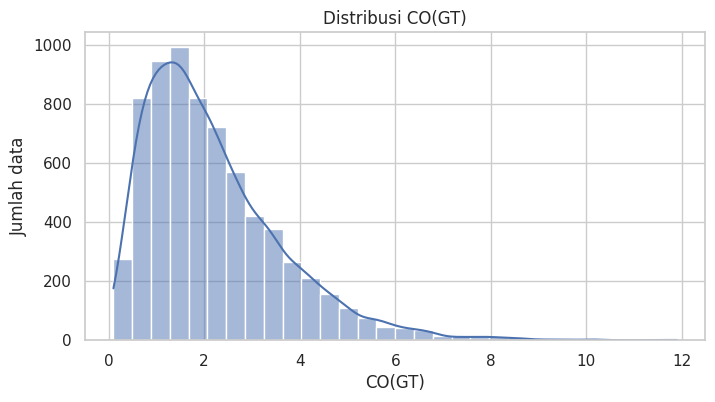

In [24]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi CO(GT)")
plt.xlabel("CO(GT)")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Sebagian besar nilai `CO(GT)` muncul pada rentang rendah, sekitar **0 sampai 3**.

> Apakah bentuk distribusinya mendekati lonceng sempurna atau condong ke salah satu sisi?

Jawaban: Distribusi condong ke kanan karena ada beberapa nilai `CO(GT)` yang jauh lebih tinggi.

### Hitung korelasi fitur dengan target

Hitung korelasi setiap fitur terhadap target.

In [25]:
corr_with_target = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
corr_with_target

C6H6(GT)         0.930
PT08.S2(NMHC)    0.914
PT08.S1(CO)      0.877
PT08.S5(O3)      0.853
NOx(GT)          0.786
NO2(GT)          0.674
PT08.S4(NO2)     0.631
RH               0.065
AH               0.059
T                0.018
PT08.S3(NOx)    -0.701
Name: CO(GT), dtype: float64

> Berdasarkan output korelasi, fitur apa saja yang memiliki korelasi positif paling terlihat terhadap target?

Jawaban: `C6H6(GT)`, `PT08.S2(NMHC)`, `PT08.S1(CO)`, dan `PT08.S5(O3)` memiliki korelasi positif kuat terhadap target.

> Fitur apa yang memiliki korelasi negatif terhadap target?

Jawaban: `PT08.S3(NOx)` memiliki korelasi negatif paling terlihat terhadap target.

### Buat bar plot korelasi

Gunakan bar plot untuk melihat korelasi fitur dengan target secara visual.

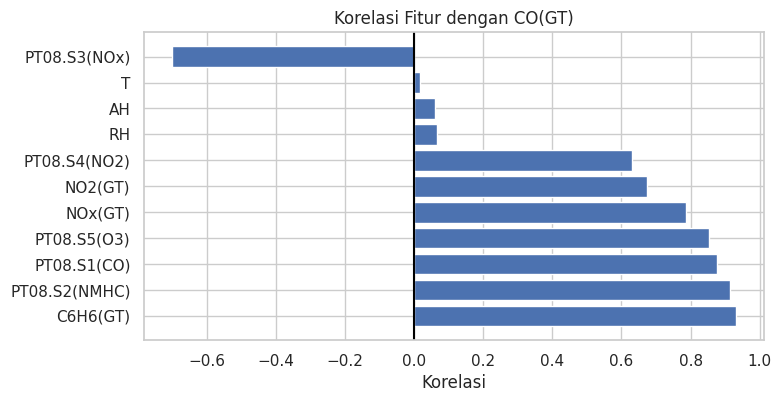

In [26]:
plt.figure(figsize=(8, 4))
plt.barh(corr_with_target.index, corr_with_target.values)
plt.axvline(0, color="black")
plt.title("Korelasi Fitur dengan CO(GT)")
plt.xlabel("Korelasi")
plt.show()

> Berdasarkan bar plot, fitur mana yang berada pada sisi korelasi positif dan sisi korelasi negatif?

Jawaban: Sebagian besar fitur berada pada sisi positif, sedangkan `PT08.S3(NOx)` berada pada sisi negatif.

> Apa arti arah korelasi tersebut terhadap target?

Jawaban: Korelasi positif berarti nilai fitur cenderung naik bersama target, sedangkan korelasi negatif berarti nilai fitur cenderung naik ketika target menurun.

### Buat scatter plot C6H6 dan target

Gunakan scatter plot dengan garis tren untuk melihat hubungan `C6H6(GT)` dengan target.

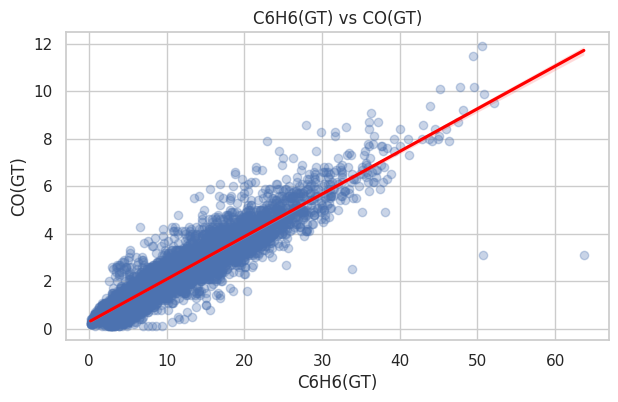

In [27]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=df_clean,
    x="C6H6(GT)",
    y=TARGET_COL,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("C6H6(GT) vs CO(GT)")
plt.xlabel("C6H6(GT)")
plt.ylabel("CO(GT)")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `C6H6(GT)` dengan target?

Jawaban: Semakin tinggi `C6H6(GT)`, nilai `CO(GT)` cenderung ikut meningkat.

> Apakah garis tren menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis tren menunjukkan arah hubungan **positif**.

### Buat scatter plot PT08.S3(NOx) dan target

Gunakan scatter plot dengan garis tren untuk melihat hubungan `PT08.S3(NOx)` dengan target.

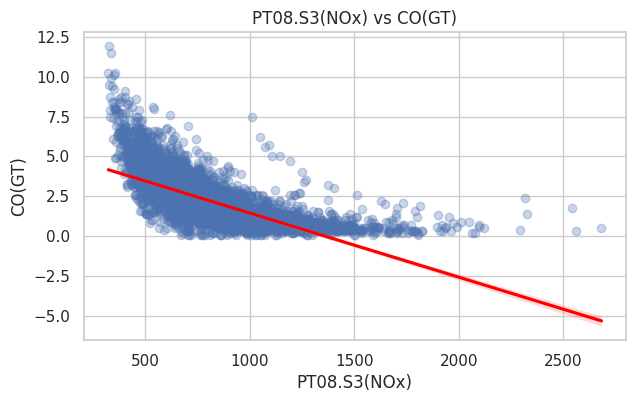

In [28]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=df_clean,
    x="PT08.S3(NOx)",
    y=TARGET_COL,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("PT08.S3(NOx) vs CO(GT)")
plt.xlabel("PT08.S3(NOx)")
plt.ylabel("CO(GT)")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan `PT08.S3(NOx)` dengan target?

Jawaban: Semakin tinggi `PT08.S3(NOx)`, nilai `CO(GT)` cenderung lebih rendah.

> Apakah garis tren menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis tren menunjukkan arah hubungan **negatif**.

## 6 - Feature dan Target

### Pisahkan fitur

Simpan semua kolom selain target ke variabel `X`.

In [29]:
X = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke variabel `y`.

In [30]:
y = df_clean[TARGET_COL]

### Tampilkan ukuran fitur

Cek ukuran `X` setelah fitur dipisahkan.

In [31]:
X.shape

(6941, 11)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki **6941 baris** dan **11 fitur**.

### Tampilkan ukuran target

Cek ukuran `y` setelah target dipisahkan.

In [32]:
y.shape

(6941,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki **6941 nilai target**.

> Apakah jumlah baris `X` dan `y` sudah sama?

Jawaban: Ya, jumlah baris `X` dan `y` sudah sama, yaitu **6941**.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [33]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji yang digunakan adalah **20%**, sedangkan data latih adalah **80%** dari seluruh dataset.

### Bagi data train dan test

Bagi data menjadi data train dan test.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Cek jumlah data dan fitur pada `X_train`.

In [35]:
X_train.shape

(5552, 11)

### Tampilkan ukuran X_test

Cek jumlah data dan fitur pada `X_test`.

In [36]:
X_test.shape

(1389, 11)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki **5552 baris**, sedangkan data test memiliki **1389 baris**.

> Apakah jumlah fitur pada train dan test tetap sama?

Jawaban: Ya, jumlah fitur pada train dan test tetap sama, yaitu **11 fitur**.

## 8 - Feature Scaling

### Buat object scaler

Gunakan `StandardScaler` untuk menstandarkan fitur.

In [37]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler hanya pada data train, lalu transform data train.

In [38]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Transform data test menggunakan scaler yang sudah di-fit pada data train.

In [39]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [40]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [41]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan untuk prediksi?

Jawaban: Output `LinearRegression()` menunjukkan bahwa object model sudah berhasil dilatih dan siap digunakan untuk prediksi.

### Tampilkan intercept model

Tampilkan nilai intercept dari model.

In [42]:
model.intercept_

np.float64(2.181934438040345)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar **2.18**.

> Apa makna intercept setelah seluruh fitur di-scale?

Jawaban: Intercept adalah nilai dasar prediksi ketika seluruh fitur berada pada titik nol setelah scaling.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel sederhana.

In [43]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
1,C6H6(GT),0.877
3,NOx(GT),0.321
0,PT08.S1(CO),0.293
6,PT08.S4(NO2),0.200
5,NO2(GT),0.114
4,PT08.S3(NOx),0.064
10,AH,0.004
2,PT08.S2(NMHC),-0.035
9,RH,-0.076
7,PT08.S5(O3),-0.141


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar dan koefisien negatif terbesar?

Jawaban: Koefisien positif terbesar adalah `C6H6(GT)` sekitar **0.88**, sedangkan koefisien negatif terbesar adalah `T` sekitar **-0.18**.

> Apa arti tanda positif dan negatif pada koefisien?

Jawaban: Koefisien positif berarti fitur cenderung menaikkan prediksi, sedangkan koefisien negatif berarti fitur cenderung menurunkan prediksi.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk memprediksi data train.

In [44]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk memprediksi data test.

In [45]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama dari data test.

In [46]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_test_pred[:5]
})
prediction_preview

,Actual,Predicted
0,2.800,2.984
1,1.100,1.277
2,3.700,3.001
3,1.700,1.730
4,1.900,2.000


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dan paling jauh dari nilai aktual?

Jawaban: Prediksi paling dekat terlihat pada baris ke-5, dengan aktual **1.90** dan prediksi **2.00**. Prediksi paling jauh terlihat pada baris ke-3, dengan aktual **3.70** dan prediksi **3.00**.

> Apa yang bisa disimpulkan dari selisih aktual dan prediksi?

Jawaban: Beberapa prediksi cukup dekat dengan nilai aktual, walaupun masih ada selisih pada beberapa baris.

### Hitung MAE train

Hitung rata-rata error absolut pada data train.

In [47]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

0.27211083856234897

### Hitung MAE test

Hitung rata-rata error absolut pada data test.

In [48]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

0.25838639316827844

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar **0.26**.

> Apa arti rata-rata error absolut tersebut?

Jawaban: Artinya, rata-rata prediksi model meleset sekitar **0.26** dari nilai `CO(GT)` aktual.

### Hitung RMSE train

Hitung RMSE pada data train.

In [49]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(0.439549808695279)

### Hitung RMSE test

Hitung RMSE pada data test.

In [50]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(0.39777101524935177)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar **0.40**.

> Mengapa nilai RMSE dapat lebih besar daripada MAE?

Jawaban: RMSE dapat lebih besar daripada MAE karena RMSE memberi penalti lebih besar pada error yang besar.

### Hitung R2 train

Hitung R2 Score pada data train.

In [51]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.9090292401968

### Hitung R2 test

Hitung R2 Score pada data test.

In [52]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.9162005100037094

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar **0.92**.

> Berapa persen variasi target pada data test yang dapat dijelaskan oleh model?

Jawaban: Model dapat menjelaskan sekitar **92%** variasi `CO(GT)` pada data test.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 ke dalam satu tabel ringkas.

In [53]:
evaluation_table = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})
evaluation_table

,Subset,MAE,RMSE,R2
0,Train,0.272,0.440,0.909
1,Test,0.258,0.398,0.916


> Berdasarkan tabel evaluasi, bandingkan MAE, RMSE, dan R2 pada data train dan data test.

Jawaban: MAE test lebih kecil daripada MAE train, RMSE test lebih kecil daripada RMSE train, dan R2 test sedikit lebih besar daripada R2 train.

> Berapa persen perbedaannya, dan apa makna perbandingan tersebut?

Jawaban: MAE test sekitar **5.04%** lebih kecil, RMSE test sekitar **9.50%** lebih kecil, dan R2 test sekitar **0.79%** lebih besar dibanding train. Performa train dan test terlihat seimbang.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk melihat kedekatan nilai aktual dan prediksi pada data test.

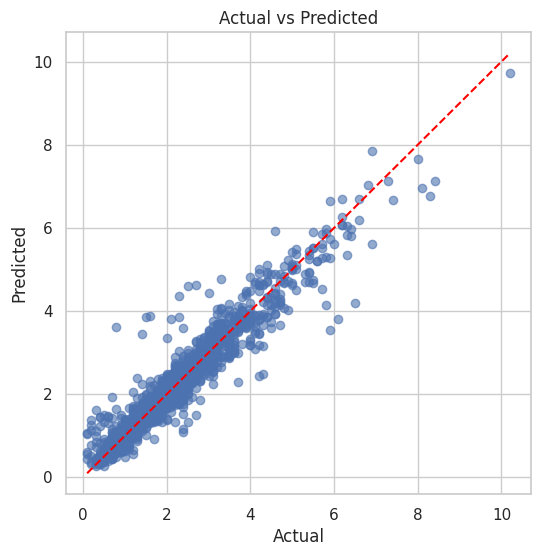

In [54]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 11 - Kesimpulan

Dataset Air Quality digunakan untuk memprediksi `CO(GT)` berdasarkan data sensor kualitas udara. Data awal tidak memiliki missing value standar, tetapi memiliki banyak nilai sentinel `-200` yang diperlakukan sebagai missing value. Setelah cleaning, dataset memiliki **6941** baris dan **12** kolom.

Hasil EDA menunjukkan bahwa `C6H6(GT)`, `PT08.S2(NMHC)`, dan `PT08.S1(CO)` memiliki hubungan positif dengan target, sedangkan `PT08.S3(NOx)` cenderung memiliki hubungan negatif. Data dibagi menjadi **80%** data train dan **20%** data test, lalu fitur di-scale menggunakan `StandardScaler`.

Model Linear Regression menghasilkan MAE test sekitar **0.26**, RMSE test sekitar **0.40**, dan R2 test sekitar **0.92**. Berdasarkan metrik tersebut, model mampu menjelaskan sekitar **92%** variasi target pada data test dengan rata-rata error absolut sekitar **0.26**.